    ad_id reporting_start reporting_end campaign_id fb_campaign_id    age  \
0  708746      17/08/2017    17/08/2017         916         103916  30-34   
1  708749      17/08/2017    17/08/2017         916         103917  30-34   
2  708771      17/08/2017    17/08/2017         916         103920  30-34   
3  708815      30/08/2017    30/08/2017         916         103928  30-34   
4  708818      17/08/2017    17/08/2017         916         103928  30-34   

  gender  interest1  interest2  interest3  impressions  clicks  spent  \
0      M         15         17         17       7350.0       1   1.43   
1      M         16         19         21      17861.0       2   1.82   
2      M         20         25         22        693.0       0   0.00   
3      M         28         32         32       4259.0       1   1.25   
4      M         28         33         32       4133.0       1   1.29   

   total_conversion  approved_conversion  
0               2.0                  1.0  
1           

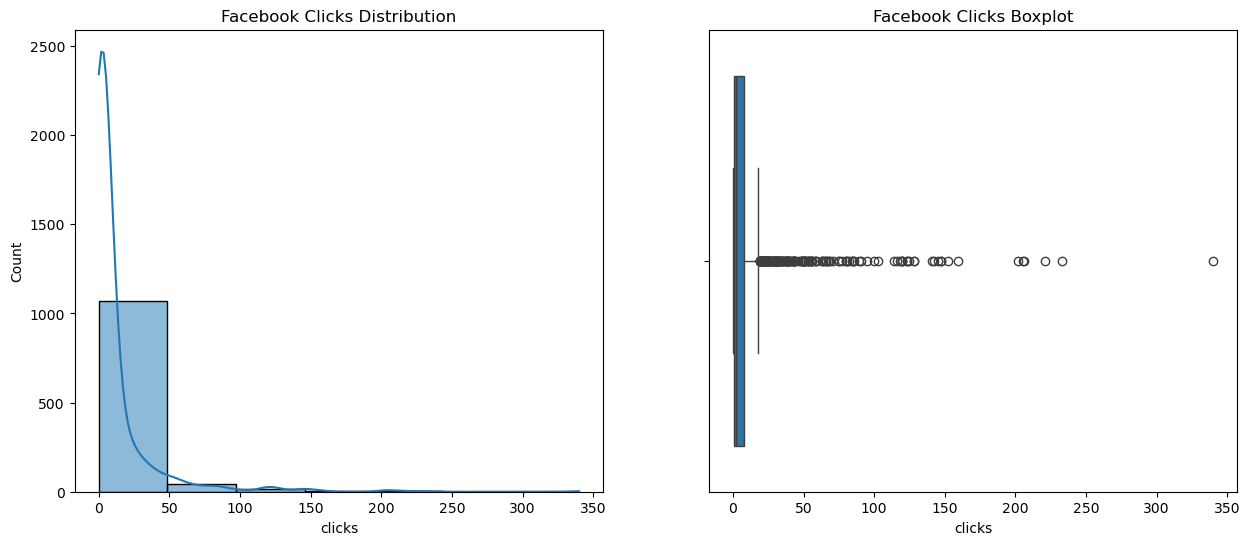

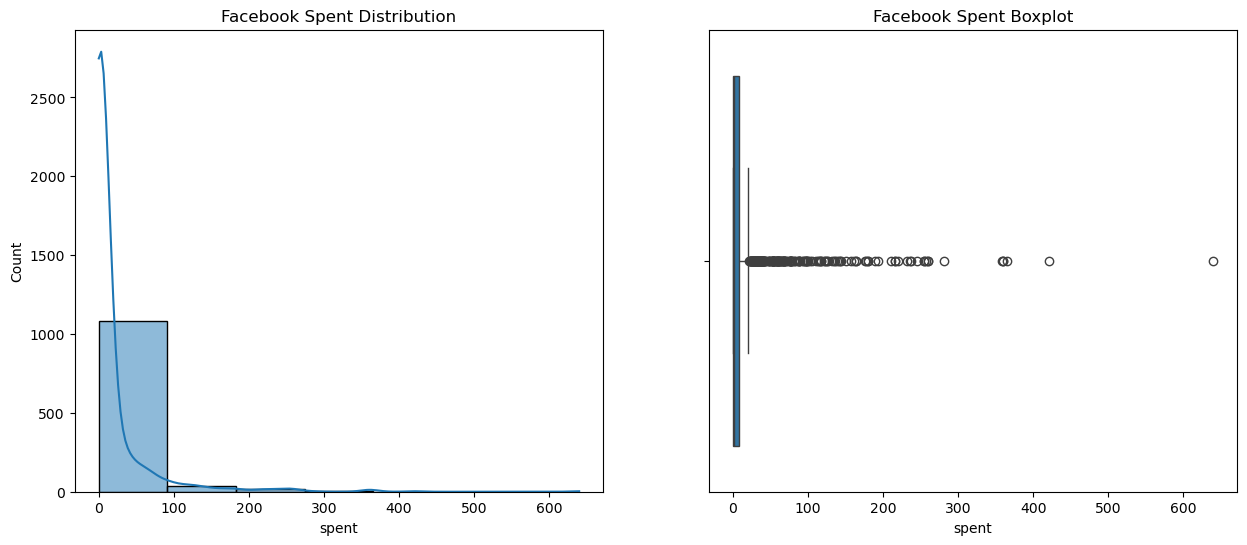

      category  facebook_count  clicks_count  spent_count
0       1 to 5             339           574          438
1  More than 5             396           363          351
2         Zero             408           206          354


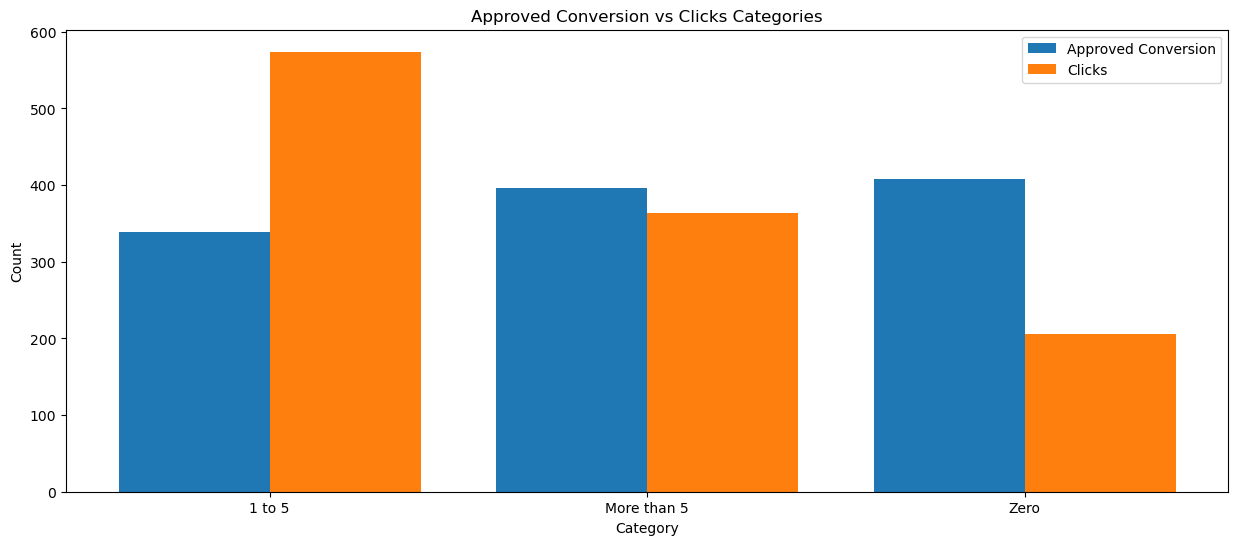

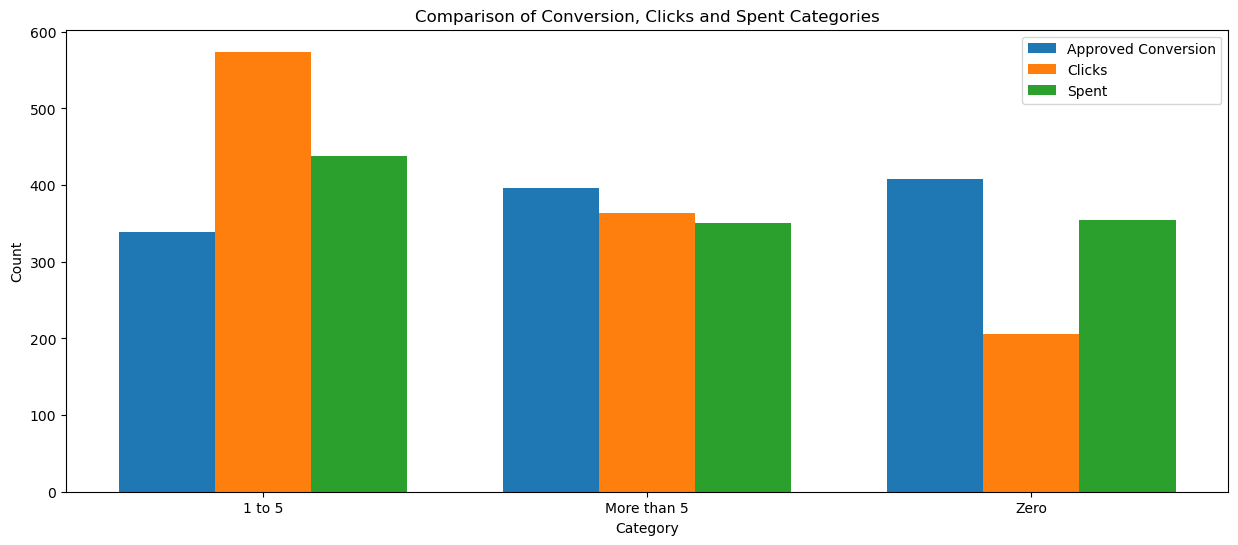

                     impressions    clicks     spent  total_conversion  \
impressions             1.000000  0.965629  0.980918          0.885863   
clicks                  0.965629  1.000000  0.992596          0.808487   
spent                   0.980918  0.992596  1.000000          0.825692   
total_conversion        0.885863  0.808487  0.825692          1.000000   
approved_conversion     0.761856  0.673458  0.687713          0.881020   

                     approved_conversion  
impressions                     0.761856  
clicks                          0.673458  
spent                           0.687713  
total_conversion                0.881020  
approved_conversion             1.000000  


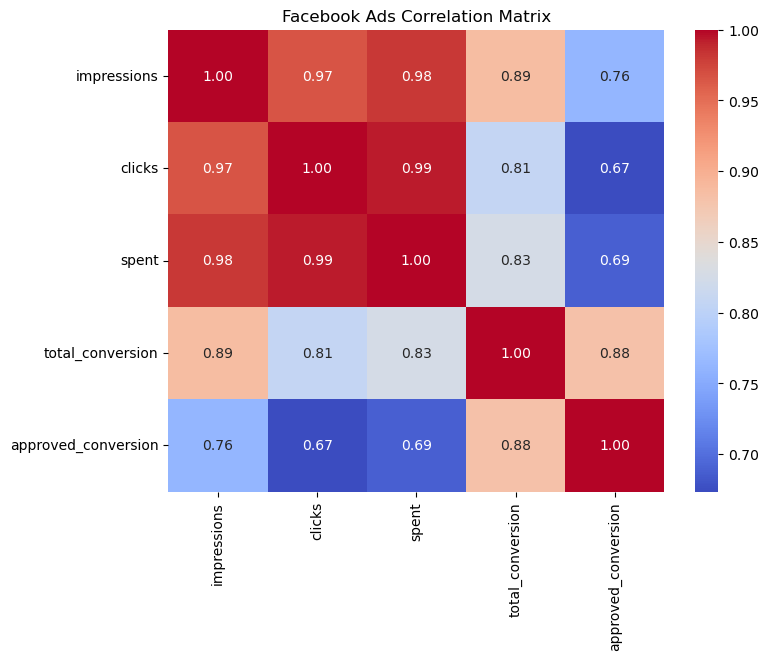

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv(r"D:\3rd Year\data.csv")

# Dataset Overview
print(df.head())
print("Shape:", df.shape)
print(df.dtypes)

# ----------------------------------
# Distribution of Clicks and Spent
# ----------------------------------

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['clicks'], bins=7, edgecolor='k', kde=True)
plt.title('Facebook Clicks Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['clicks'])
plt.title('Facebook Clicks Boxplot')

plt.show()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['spent'], bins=7, edgecolor='k', kde=True)
plt.title('Facebook Spent Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['spent'])
plt.title('Facebook Spent Boxplot')

plt.show()

# ----------------------------------
# Create Categories
# ----------------------------------

def create_conversion_category(value):
    if value == 0:
        return 'Zero'
    elif value <= 5:
        return '1 to 5'
    else:
        return 'More than 5'

# Categories for Approved Conversion
df['conversion_category'] = df['approved_conversion'].apply(create_conversion_category)

# Categories for Clicks
df['clicks_category'] = df['clicks'].apply(create_conversion_category)

# Categories for Spent
df['spent_category'] = df['spent'].apply(create_conversion_category)

# ----------------------------------
# Frequency Tables
# ----------------------------------

facebook = (
    df['conversion_category']
    .value_counts()
    .reset_index()
)

facebook.columns = ['category', 'facebook_count']

clicks = (
    df['clicks_category']
    .value_counts()
    .reset_index()
)

clicks.columns = ['category', 'clicks_count']

spent = (
    df['spent_category']
    .value_counts()
    .reset_index()
)

spent.columns = ['category', 'spent_count']

# Merge DataFrames
category_df = (
    facebook
    .merge(clicks, on='category', how='outer')
    .merge(spent, on='category', how='outer')
    .fillna(0)
)

print(category_df)

# ----------------------------------
# Bar Chart: Facebook vs Clicks
# ----------------------------------

X_axis = np.arange(len(category_df))

plt.figure(figsize=(15, 6))

plt.bar(
    X_axis - 0.2,
    category_df['facebook_count'],
    0.4,
    label='Approved Conversion'
)

plt.bar(
    X_axis + 0.2,
    category_df['clicks_count'],
    0.4,
    label='Clicks'
)

plt.xticks(X_axis, category_df['category'])
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Approved Conversion vs Clicks Categories")
plt.legend()

plt.show()

# ----------------------------------
# Compare All Three Metrics
# ----------------------------------

plt.figure(figsize=(15, 6))

plt.bar(
    X_axis - 0.25,
    category_df['facebook_count'],
    0.25,
    label='Approved Conversion'
)

plt.bar(
    X_axis,
    category_df['clicks_count'],
    0.25,
    label='Clicks'
)

plt.bar(
    X_axis + 0.25,
    category_df['spent_count'],
    0.25,
    label='Spent'
)

plt.xticks(X_axis, category_df['category'])
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Comparison of Conversion, Clicks and Spent Categories")
plt.legend()

plt.show()

# ----------------------------------
# Correlation Analysis
# ----------------------------------

facebook_corr = df[
    [
        'impressions',
        'clicks',
        'spent',
        'total_conversion',
        'approved_conversion'
    ]
].corr()

print(facebook_corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    facebook_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Facebook Ads Correlation Matrix")
plt.show()

In [2]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['spent'], df['approved_conversion'])

print("Correlation:", corr)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Significant relationship exists.")
else:
    print("Fail to Reject H0: No significant relationship.")

Correlation: nan
P-value: nan
Fail to Reject H0: No significant relationship.


In [6]:
# Do Men and Women Have Different Numbers of Approved Conversions?
import scipy.stats as st
male = df[df['gender'] == 'M']['approved_conversion']
female = df[df['gender'] == 'F']['approved_conversion']

t_stat, p_value = st.ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.968168442412852
P-value: 8.356382812558637e-07


In [7]:
groups = [
    group['approved_conversion'].values
    for _, group in df.groupby('age')
]

f_stat, p_value = st.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: nan
P-value: nan


In [9]:
# Regression Analysis

# 

In [11]:
X = df[['impressions', 'clicks', 'spent']]
y = df['approved_conversion']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

print("R² Score:", r2_score(y, y_pred))

ValueError: Input y contains NaN.

In [12]:
print(df['approved_conversion'].isnull().sum())

382


In [13]:
df_reg = df[['spent', 'approved_conversion']].dropna()

X = df_reg[['spent']]
y = df_reg['approved_conversion']

In [14]:
df['approved_conversion'] = df['approved_conversion'].fillna(
    df['approved_conversion'].median()
)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Remove missing values
df_reg = df[['spent', 'approved_conversion']].dropna()

X = df_reg[['spent']]
y = df_reg['approved_conversion']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R² Score:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

Intercept: 0.15243105168606785
Coefficient: 0.020421915418050697
R² Score: 0.49945140471501603
RMSE: 0.9894552130190138


Predicted Approved Conversions for 50 Clicks: 1.855376097513362


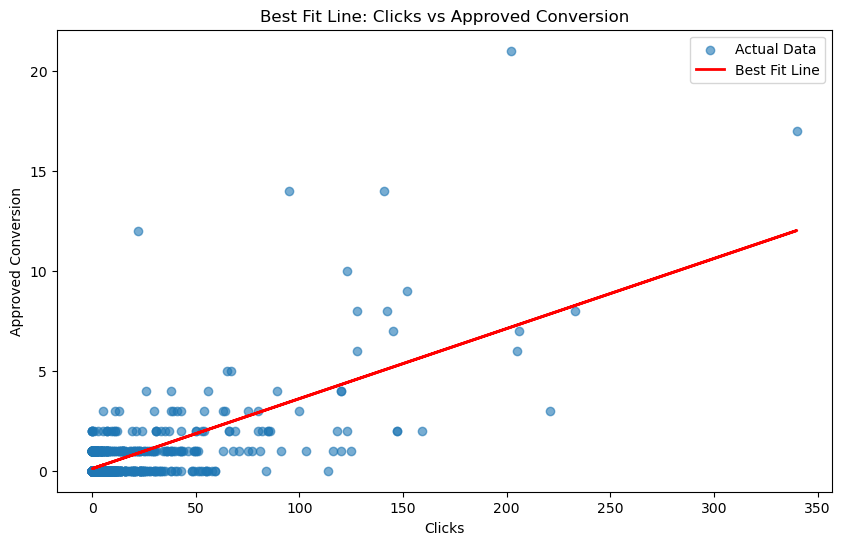

Intercept (b): 0.1045781867376902
Slope (m): 0.03501595821551343
Equation: y = 0.0350x + 0.1046


In [16]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Remove missing values
df_reg = df[['clicks', 'approved_conversion']].dropna()

# Independent Variable
X = df_reg[['clicks']]

# Dependent Variable
y = df_reg['approved_conversion']

# Train Model
model = LinearRegression()
model.fit(X, y)

# Prediction for 50 clicks
predicted_conversion = model.predict([[50]])

print("Predicted Approved Conversions for 50 Clicks:",
      predicted_conversion[0])

# Best Fit Line
y_pred = model.predict(X)

plt.figure(figsize=(10,6))
plt.scatter(df_reg['clicks'],
            df_reg['approved_conversion'],
            alpha=0.6,
            label='Actual Data')

plt.plot(df_reg['clicks'],
         y_pred,
         color='red',
         linewidth=2,
         label='Best Fit Line')

plt.xlabel('Clicks')
plt.ylabel('Approved Conversion')
plt.title('Best Fit Line: Clicks vs Approved Conversion')
plt.legend()
plt.show()

# Equation of the line
print("Intercept (b):", model.intercept_)
print("Slope (m):", model.coef_[0])

print(f"Equation: y = {model.coef_[0]:.4f}x + {model.intercept_:.4f}")